# E-Commerce Fulfillment Simulation

For this project, I modeled what happens after a customer places an online order: the order is picked and packed at a fulfillment center, moved to a distribution center, and delivered to the customer.

I built the model in Python with [SimPy](https://simpy.readthedocs.io/) instead of Simio.

Here is where each part of the project appears in the notebook:

| Project requirement | Notebook section |
|---------------------|------------------|
| Concept model | Section 1 |
| SimPy resources | Sections 2-3 |
| Process logic | Section 3 |
| Explanation of each process | Notes before each stage |
| Model performance | Section 4 |


## 1. Concept model

I based the model on a simplified Amazon-style fulfillment process. I assume the item is already in stock at the fulfillment center, so the model follows one path from the customer's purchase to final delivery. I didn't include third-party seller shipping is outside the scope of this version.

```
Customer places an order (Source)
    |  order is created instantly
    v
Fulfillment center queue
    |  pickers process and pack each order
    v
Packed dock
    |  packages are combined onto a transfer truck
    v
Middle-mile trip (FC -> Distribution Center)
    v
DC inbound queue
    |  DC workers sort packages by delivery route
    v
Route lanes (one for each driver territory)
    |  drivers leave during scheduled delivery waves
    v
Customer receives the package (Sink)
```

### Main parts of the model

I tried to simulate Simio's objects in this model: 

| Concept | How I used it |
|---------|---------------|
| **Entity** | An `Order`, which becomes a package after pick/pack |
| **Source** | The customer purchase process |
| **Queue / Store** | FC inbound, packed dock, DC inbound, and route lanes |
| **Server** | FC pickers and DC workers |
| **Combiner** | A transfer truck that carries a batch of packages |
| **Mobile resource** | Drivers and vans assigned to fixed routes |
| **Sink** | Completed customer delivery |

### Assumptions

- Every item is in stock at the fulfillment center.
- Demand averages about 100 orders per day.
- I use triangular distributions for all random process times.
- Each order is assigned to a fixed driver territory through its `route_id`.
- Drivers leave during scheduled morning and evening waves instead of leaving continuously.


## 2. Setup and configuration

I kept the model settings together in the next cell so they are easy to find and adjust. These values play the same role as object properties in Simio.

In [1]:
from __future__ import annotations

import random
from dataclasses import dataclass

import simpy

# ---------------------------------------------------------------------------
# Random seed (reproducible runs)
# ---------------------------------------------------------------------------
RANDOM_SEED = 42

# ---------------------------------------------------------------------------
# Horizon
# ---------------------------------------------------------------------------
SIM_DAYS = 2
MINUTES_PER_DAY = 24 * 60
SIM_MINUTES = SIM_DAYS * MINUTES_PER_DAY

# ---------------------------------------------------------------------------
# Demand: ~100 orders/day
# Mean of triangular ~ (min + mode + max) / 3 ~ 14.3 min -> ~100/day
# ---------------------------------------------------------------------------
ORDERS_PER_DAY = 100
ARRIVAL_MIN, ARRIVAL_MODE, ARRIVAL_MAX = 8.0, 12.0, 23.0

# ---------------------------------------------------------------------------
# Fulfillment center (pick / pack servers)
# ---------------------------------------------------------------------------
NUM_PICKERS = 2
PICK_MIN, PICK_MODE, PICK_MAX = 5.0, 10.0, 20.0

# ---------------------------------------------------------------------------
# Combiner: ship ASAP to distribution center
# Depart when batch is full OR first package has waited TRANSFER_MAX_WAIT
# ---------------------------------------------------------------------------
TRANSFER_BATCH_SIZE = 15
TRANSFER_MAX_WAIT = 45.0  # minutes
TRANSFER_LOAD_MIN, TRANSFER_LOAD_MODE, TRANSFER_LOAD_MAX = 10.0, 20.0, 35.0
TRANSIT_MIN, TRANSIT_MODE, TRANSIT_MAX = 30.0, 60.0, 120.0  # FC -> DC

# ---------------------------------------------------------------------------
# Distribution center (sort onto routes)
# ---------------------------------------------------------------------------
NUM_DC_WORKERS = 2
DC_PROCESS_MIN, DC_PROCESS_MODE, DC_PROCESS_MAX = 2.0, 5.0, 10.0

# ---------------------------------------------------------------------------
# Last mile: fixed routes, wave departures
# ---------------------------------------------------------------------------
NUM_DRIVERS = 4
VAN_CAPACITY = 20
WAVE_HOURS = [8.0, 17.0]  # morning + evening
LOAD_MIN, LOAD_MODE, LOAD_MAX = 15.0, 25.0, 40.0
TRAVEL_MIN, TRAVEL_MODE, TRAVEL_MAX = 5.0, 15.0, 40.0
DROPOFF_MIN, DROPOFF_MODE, DROPOFF_MAX = 1.0, 3.0, 8.0
RETURN_TO_DC_MIN, RETURN_TO_DC_MODE, RETURN_TO_DC_MAX = 10.0, 20.0, 40.0

print("Config loaded.")
print(f"  SIM_DAYS={SIM_DAYS}, ORDERS_PER_DAY~{ORDERS_PER_DAY}")
print(f"  pickers={NUM_PICKERS}, dc_workers={NUM_DC_WORKERS}, drivers={NUM_DRIVERS}")
print(f"  waves={WAVE_HOURS}, transfer batch={TRANSFER_BATCH_SIZE} or wait={TRANSFER_MAX_WAIT} min")


Config loaded.
  SIM_DAYS=2, ORDERS_PER_DAY~100
  pickers=2, dc_workers=2, drivers=4
  waves=[8.0, 17.0], transfer batch=15 or wait=45.0 min


### Helper functions

I use three small helper functions throughout the model:

- `tri` draws a value from a triangular distribution.
- `mean` calculates an average for the performance measures.
- `next_wave_time` finds the next scheduled time when a driver can leave.

In [2]:
def tri(lo: float, mode: float, hi: float) -> float:
    """Triangular random time (minutes)."""
    return random.triangular(lo, hi, mode)


def mean(xs: list[float]) -> float:
    return sum(xs) / len(xs) if xs else 0.0


def next_wave_time(now: float) -> float:
    """Absolute sim minute of the next driver wave."""
    day = int(now // MINUTES_PER_DAY)
    for d in range(day, day + 3):
        for h in WAVE_HOURS:
            t = d * MINUTES_PER_DAY + h * 60.0
            if t > now + 1e-9:
                return t
    return now + MINUTES_PER_DAY

### Order entity

Each customer purchase creates one `Order`. The order keeps its timestamps as it moves through the system, which lets me calculate waiting times and total delivery lead time later.

In [3]:
@dataclass
class Order:
    order_id: int
    route_id: int  # fixed driver territory
    created_at: float
    entered_fc_queue_at: float | None = None
    pick_start_at: float | None = None
    pick_end_at: float | None = None
    transfer_depart_at: float | None = None
    arrived_dc_at: float | None = None
    dc_process_end_at: float | None = None
    loaded_on_van_at: float | None = None
    delivered_at: float | None = None
    picker_id: int | None = None
    transfer_id: int | None = None
    driver_id: int | None = None

## 3. Process logic

Each function below represents one SimPy process. When they run together, they create the full fulfillment flow shown in the concept model.

### 3.1 Customer purchase (Source)

Orders arrive using a triangular interarrival time that produces about 100 purchases per day. Creating the purchase and order ticket takes no simulated time. The new order goes directly into the fulfillment center queue, which is a `simpy.Store`. I also assign its `route_id` at this point by rotating through the available drivers, so the distribution center already knows which route lane to use.

In [4]:
def customer_purchase(env: simpy.Environment, fc_store: simpy.Store, stats: dict):
    """Source: buy (instant) -> FC inbound queue."""
    order_id = 0
    while True:
        yield env.timeout(tri(ARRIVAL_MIN, ARRIVAL_MODE, ARRIVAL_MAX))
        order_id += 1
        now = env.now
        route_id = ((order_id - 1) % NUM_DRIVERS) + 1

        order = Order(order_id=order_id, route_id=route_id, created_at=now)
        order.entered_fc_queue_at = now

        stats["fc_queue_len"] += 1
        stats["fc_queue_peak"] = max(stats["fc_queue_peak"], stats["fc_queue_len"])
        stats["orders_created"] += 1

        yield fc_store.put(order)

### 3.2 Fulfillment center picker (Server)

The fulfillment center has `NUM_PICKERS` picker processes working in parallel. Each picker takes the next order from the FIFO store, spends a triangular amount of time picking and packing it, and places the finished package on the packed dock. Adding a package also wakes the transfer process so it can check whether a truck should leave.

In [5]:
def fc_picker(
    env: simpy.Environment,
    picker_id: int,
    fc_store: simpy.Store,
    packed_dock: list[Order],
    packed_event: list,
    stats: dict,
):
    """FC Server: pick/pack -> packed dock."""
    while True:
        order: Order = yield fc_store.get()
        stats["fc_queue_len"] -= 1
        now = env.now

        order.pick_start_at = now
        order.picker_id = picker_id
        stats["fc_queue_waits"].append(now - (order.entered_fc_queue_at or now))

        pick_t = tri(PICK_MIN, PICK_MODE, PICK_MAX)
        yield env.timeout(pick_t)

        order.pick_end_at = env.now
        stats["pick_times"].append(pick_t)
        stats["picker_busy"][picker_id] += pick_t
        stats["orders_packed"] += 1

        packed_dock.append(order)
        ev = packed_event[0]
        if ev is not None and not ev.triggered:
            ev.succeed()

### 3.3 Transfer truck (Combiner)

This part works like a simplified Simio **Combiner**: the truck is the parent and the packed orders are its members.

A truck leaves when either:

1. It reaches `TRANSFER_BATCH_SIZE`, or
2. The first package in the batch has waited `TRANSFER_MAX_WAIT` minutes.

The maximum-wait rule keeps a truck from sitting at the dock too long when demand is slower. Once it leaves, the model adds a triangular loading time and a triangular trip from the fulfillment center to the distribution center. The full batch then enters the DC inbound store.

In [6]:
def transfer_combiner(
    env: simpy.Environment,
    packed_dock: list[Order],
    packed_event: list,
    dc_store: simpy.Store,
    stats: dict,
):
    """Combiner: batch packages onto transfer truck -> DC."""
    transfer_id = 0
    while True:
        while not packed_dock:
            packed_event[0] = env.event()
            yield packed_event[0]

        batch: list[Order] = [packed_dock.pop(0)]
        batch_start = env.now

        while len(batch) < TRANSFER_BATCH_SIZE:
            remaining = TRANSFER_MAX_WAIT - (env.now - batch_start)
            if remaining <= 0:
                break
            if packed_dock:
                batch.append(packed_dock.pop(0))
                continue
            packed_event[0] = env.event()
            timeout = env.timeout(remaining)
            result = yield packed_event[0] | timeout
            if packed_event[0] in result and packed_dock:
                batch.append(packed_dock.pop(0))
            else:
                break

        transfer_id += 1
        load_t = tri(TRANSFER_LOAD_MIN, TRANSFER_LOAD_MODE, TRANSFER_LOAD_MAX)
        yield env.timeout(load_t)

        depart = env.now
        transit_t = tri(TRANSIT_MIN, TRANSIT_MODE, TRANSIT_MAX)
        for o in batch:
            o.transfer_id = transfer_id
            o.transfer_depart_at = depart

        yield env.timeout(transit_t)

        arrive = env.now
        stats["transfers"] += 1
        stats["transfer_batch_sizes"].append(len(batch))
        stats["transit_times"].append(transit_t)

        for o in batch:
            o.arrived_dc_at = arrive
            stats["dc_queue_len"] += 1
            stats["dc_queue_peak"] = max(stats["dc_queue_peak"], stats["dc_queue_len"])
            yield dc_store.put(o)

### 3.4 Distribution center worker (Server)

I treat the distribution center as a delivery station rather than another inventory warehouse. Workers receive already packed orders, spend a triangular amount of time processing and sorting each one, and place it in the route lane that matches its `route_id`.

In [7]:
def dc_worker(
    env: simpy.Environment,
    worker_id: int,
    dc_store: simpy.Store,
    route_lanes: dict[int, list[Order]],
    stats: dict,
):
    """DC Server: process package onto driver route lane."""
    while True:
        order: Order = yield dc_store.get()
        stats["dc_queue_len"] -= 1
        now = env.now
        stats["dc_queue_waits"].append(now - (order.arrived_dc_at or now))

        proc_t = tri(DC_PROCESS_MIN, DC_PROCESS_MODE, DC_PROCESS_MAX)
        yield env.timeout(proc_t)

        order.dc_process_end_at = env.now
        stats["dc_process_times"].append(proc_t)
        stats["dc_busy"][worker_id] += proc_t
        stats["orders_sorted"] += 1

        route_lanes[order.route_id].append(order)

### 3.5 Driver (Last mile)

Each driver is responsible for one territory, so the `driver_id` matches the order's `route_id`. At each scheduled wave, a driver loads up to `VAN_CAPACITY` packages from that route lane. The model includes a triangular loading time, travel and drop-off time for every stop, and a return trip to the distribution center. If the lane is empty when a wave begins, the driver skips that tour.


In [8]:
def driver(
    env: simpy.Environment,
    driver_id: int,
    route_lanes: dict[int, list[Order]],
    stats: dict,
):
    """Fixed-route driver: wave load -> multi-stop deliver -> return."""
    lane = route_lanes[driver_id]
    tour_id = 0

    while True:
        tw = next_wave_time(env.now)
        yield env.timeout(tw - env.now)

        if not lane:
            continue

        batch: list[Order] = []
        while lane and len(batch) < VAN_CAPACITY:
            batch.append(lane.pop(0))

        tour_id += 1
        load_t = tri(LOAD_MIN, LOAD_MODE, LOAD_MAX)
        yield env.timeout(load_t)

        depart = env.now
        for o in batch:
            o.loaded_on_van_at = depart
            o.driver_id = driver_id

        stats["tours"] += 1
        stats["tour_sizes"].append(len(batch))
        stats["driver_busy"][driver_id] += load_t

        for order in batch:
            travel_t = tri(TRAVEL_MIN, TRAVEL_MODE, TRAVEL_MAX)
            drop_t = tri(DROPOFF_MIN, DROPOFF_MODE, DROPOFF_MAX)
            yield env.timeout(travel_t)
            yield env.timeout(drop_t)

            order.delivered_at = env.now
            stats["delivered"] += 1
            stats["lead_times"].append(order.delivered_at - order.created_at)
            stats["travel_times"].append(travel_t)
            stats["dropoff_times"].append(drop_t)
            stats["driver_busy"][driver_id] += travel_t + drop_t

        ret_t = tri(RETURN_TO_DC_MIN, RETURN_TO_DC_MODE, RETURN_TO_DC_MAX)
        yield env.timeout(ret_t)
        stats["driver_busy"][driver_id] += ret_t

### 3.6 Building and running the model

The next cell connects the queues and processes in one SimPy environment, starts the workers and drivers, and runs the simulation for `SIM_MINUTES`.

In [9]:
def run_simulation() -> dict:
    """Create environment, resources/queues, start processes, return stats."""
    random.seed(RANDOM_SEED)
    env = simpy.Environment()

    # --- SimPy resources / holding areas ---
    fc_store = simpy.Store(env)  # FC inbound queue
    packed_dock: list[Order] = []  # combiner member queue
    packed_event: list = [None]  # wake-up for combiner
    dc_store = simpy.Store(env)  # DC inbound queue
    route_lanes: dict[int, list[Order]] = {
        i: [] for i in range(1, NUM_DRIVERS + 1)
    }

    stats = {
        "orders_created": 0,
        "orders_packed": 0,
        "orders_sorted": 0,
        "delivered": 0,
        "transfers": 0,
        "tours": 0,
        "fc_queue_len": 0,
        "fc_queue_peak": 0,
        "dc_queue_len": 0,
        "dc_queue_peak": 0,
        "fc_queue_waits": [],
        "dc_queue_waits": [],
        "pick_times": [],
        "dc_process_times": [],
        "transfer_batch_sizes": [],
        "transit_times": [],
        "tour_sizes": [],
        "lead_times": [],
        "travel_times": [],
        "dropoff_times": [],
        "picker_busy": {i: 0.0 for i in range(1, NUM_PICKERS + 1)},
        "dc_busy": {i: 0.0 for i in range(1, NUM_DC_WORKERS + 1)},
        "driver_busy": {i: 0.0 for i in range(1, NUM_DRIVERS + 1)},
        "still_fc": 0,
        "still_packed": 0,
        "still_dc": 0,
        "still_lanes": 0,
    }

    env.process(customer_purchase(env, fc_store, stats))
    for pid in range(1, NUM_PICKERS + 1):
        env.process(
            fc_picker(env, pid, fc_store, packed_dock, packed_event, stats)
        )
    env.process(
        transfer_combiner(env, packed_dock, packed_event, dc_store, stats)
    )
    for wid in range(1, NUM_DC_WORKERS + 1):
        env.process(dc_worker(env, wid, dc_store, route_lanes, stats))
    for did in range(1, NUM_DRIVERS + 1):
        env.process(driver(env, did, route_lanes, stats))

    env.run(until=SIM_MINUTES)

    stats["still_fc"] = len(fc_store.items)
    stats["still_packed"] = len(packed_dock)
    stats["still_dc"] = len(dc_store.items)
    stats["still_lanes"] = sum(len(v) for v in route_lanes.values())
    return stats


stats = run_simulation()
print("Simulation finished.")
print(f"  created={stats['orders_created']}, packed={stats['orders_packed']}, "
      f"sorted={stats['orders_sorted']}, delivered={stats['delivered']}")

Simulation finished.
  created=203, packed=203, sorted=189, delivered=159


## 4. Model performance

This section looks at throughput, queues, lead time, and resource use. I use the saved results from the two-day run with seed 42, so the discussion matches the numbers printed by the notebook.

In [10]:
print("=" * 64)
print("SIMULATION SUMMARY")
print("=" * 64)
print(f"Simulated days:              {SIM_DAYS}")
print(f"Orders created:              {stats['orders_created']}")
print(f"Orders packed (FC):          {stats['orders_packed']}")
print(f"Orders sorted (DC):          {stats['orders_sorted']}")
print(f"Orders delivered:            {stats['delivered']}")
print(f"Transfer departures:         {stats['transfers']}")
print(f"Driver tours:                {stats['tours']}")
print()
print("In-system at end (not delivered):")
wip = (
    stats["still_fc"]
    + stats["still_packed"]
    + stats["still_dc"]
    + stats["still_lanes"]
)
print(f"  FC queue:                  {stats['still_fc']}")
print(f"  Packed dock:               {stats['still_packed']}")
print(f"  DC inbound:                {stats['still_dc']}")
print(f"  Route lanes:               {stats['still_lanes']}")
print(f"  Total WIP:                 {wip}")
print()
print("Queues:")
print(f"  Peak FC queue:             {stats['fc_queue_peak']}")
print(f"  Peak DC queue:             {stats['dc_queue_peak']}")
if stats["fc_queue_waits"]:
    print(f"  Mean FC wait (min):        {mean(stats['fc_queue_waits']):.2f}")
    print(f"  Max  FC wait (min):        {max(stats['fc_queue_waits']):.2f}")
if stats["dc_queue_waits"]:
    print(f"  Mean DC wait (min):        {mean(stats['dc_queue_waits']):.2f}")
    print(f"  Max  DC wait (min):        {max(stats['dc_queue_waits']):.2f}")
print()
print("Times (minutes):")
if stats["pick_times"]:
    print(f"  Mean pick/pack:            {mean(stats['pick_times']):.2f}")
if stats["transit_times"]:
    print(f"  Mean FC->DC transit:       {mean(stats['transit_times']):.2f}")
if stats["dc_process_times"]:
    print(f"  Mean DC process:           {mean(stats['dc_process_times']):.2f}")
if stats["transfer_batch_sizes"]:
    print(f"  Mean transfer batch size:  {mean(stats['transfer_batch_sizes']):.2f}")
if stats["tour_sizes"]:
    print(f"  Mean tour size:            {mean(stats['tour_sizes']):.2f}")
if stats["lead_times"]:
    print(f"  Mean lead time buy->door:  {mean(stats['lead_times']):.2f}")
    print(f"  Max  lead time buy->door:  {max(stats['lead_times']):.2f}")
    print(f"  Mean lead time (hours):    {mean(stats['lead_times']) / 60.0:.2f}")
print()
if SIM_DAYS > 0:
    print(f"Orders created/day:          {stats['orders_created'] / SIM_DAYS:.1f}")
    print(f"Delivered/day:               {stats['delivered'] / SIM_DAYS:.1f}")
print()
print("Resource utilization (% of sim time busy):")
for pid, busy in stats["picker_busy"].items():
    print(f"  Picker {pid}:  {100.0 * busy / SIM_MINUTES:5.1f}%")
for wid, busy in stats["dc_busy"].items():
    print(f"  DC worker {wid}: {100.0 * busy / SIM_MINUTES:5.1f}%")
for did, busy in stats["driver_busy"].items():
    print(f"  Driver {did}:  {100.0 * busy / SIM_MINUTES:5.1f}%")

SIMULATION SUMMARY
Simulated days:              2
Orders created:              203
Orders packed (FC):          203
Orders sorted (DC):          189
Orders delivered:            159
Transfer departures:         20
Driver tours:                16

In-system at end (not delivered):
  FC queue:                  0
  Packed dock:               7
  DC inbound:                0
  Route lanes:               30
  Total WIP:                 37

Queues:
  Peak FC queue:             1
  Peak DC queue:             11
  Mean FC wait (min):        0.00
  Max  FC wait (min):        0.00
  Mean DC wait (min):        11.46
  Max  DC wait (min):        34.56

Times (minutes):
  Mean pick/pack:            11.83
  Mean FC->DC transit:       69.40
  Mean DC process:           5.83
  Mean transfer batch size:  9.45
  Mean tour size:            9.94
  Mean lead time buy->door:  709.04
  Max  lead time buy->door:  1139.25
  Mean lead time (hours):    11.82

Orders created/day:          101.5
Delivered/day:    

### What the results show

This run covers two simulated days with a target of about 100 orders per day. The model uses two pickers, two DC workers, four drivers, and delivery waves at 8:00 a.m. and 5:00 p.m.

#### Throughput

| Stage | Count | Per day | What I noticed |
|-------|------:|--------:|----------------|
| Orders created | 203 | 101.5 | The arrival process is very close to the 100-order daily target. |
| Orders packed at the FC | 203 | 101.5 | Every order was picked and packed before the run ended. |
| Orders sorted at the DC | 189 | 94.5 | Some packages were still waiting for or traveling on a transfer truck at the cutoff. |
| Orders delivered | 159 | 79.5 | Delivery falls behind creation because drivers leave only during scheduled waves. |
| Transfer trips | 20 | 10.0 | Trucks moved packages steadily between the FC and DC. |
| Driver tours | 16 | 8.0 | The four drivers completed roughly two waves per day. |

The model created 44 more orders than it delivered during the two-day window. Most of that difference is simply work still in the system when the clock stops. At the end of the run, there are no orders in the FC queue, 7 packages on the packed dock, no packages in the DC inbound queue, and 30 packages waiting in route lanes. In other words, the orders are moving through the warehouses; most of the unfinished work is waiting for the next delivery wave.

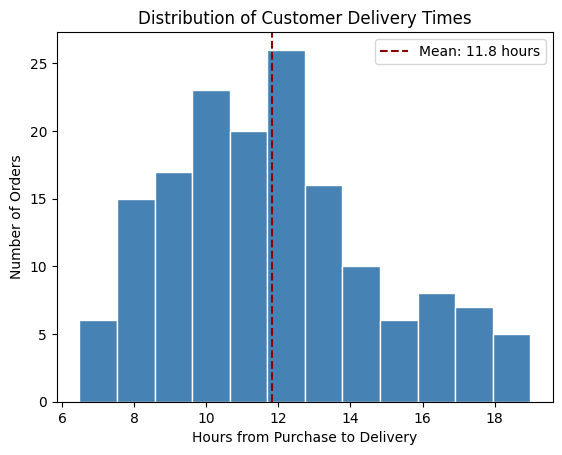

In [12]:
import matplotlib.pyplot as plt

lead_hours = [t / 60 for t in stats["lead_times"]]

plt.hist(lead_hours, bins=12, color="steelblue", edgecolor="white")
plt.axvline(
    mean(lead_hours),
    color="darkred",
    linestyle="--",
    label=f"Mean: {mean(lead_hours):.1f} hours"
)

plt.title("Distribution of Customer Delivery Times")
plt.xlabel("Hours from Purchase to Delivery")
plt.ylabel("Number of Orders")
plt.legend()
plt.show()

#### Queues and processing times

| Metric | Result | My interpretation |
|--------|-------:|-------------------|
| Peak FC queue | 1 | The pickers easily keep up with the current order volume. |
| Mean / max FC wait | 0.00 / 0.00 min | Orders can start pick/pack almost immediately. |
| Mean pick/pack time | 11.83 min | This is in line with the triangular input of 5, 10, and 20 minutes. |
| Peak DC queue | 11 | Packages arrive in truck batches, which creates short spikes. |
| Mean / max DC wait | 11.46 / 34.56 min | The waits are noticeable but do not suggest that the DC is overloaded. |
| Mean DC processing time | 5.83 min | Sorting an individual package is fairly quick. |
| Mean FC-to-DC transit | 69.40 min | The middle-mile trip adds a little over an hour on average. |
| Mean transfer batch | 9.45 of 15 | Many trucks leave because of the 45-minute limit instead of waiting until they are full. |
| Mean driver tour | 9.94 of 20 | The vans usually have room left, so van capacity is not the problem. |

#### Delivery lead time

- The average time from purchase to delivery is **709 minutes, or about 11.8 hours**.
- The longest delivery time in this run is **1,139 minutes, or about 19 hours**.

Pick/pack takes about 12 minutes on average, and DC processing takes about 6 minutes. Those steps are small compared with the total lead time. More time is spent waiting for a transfer batch, loading and traveling to the DC, waiting in a route lane for the next wave, and completing the multi-stop delivery tour.

This tells me that the schedule and transportation design matter more than warehouse processing speed in this version of the model. Adding more pickers would not make much difference because the FC queue is already almost empty. A more useful experiment would be adding another delivery wave or shortening the transfer wait limit.

#### Resource use

| Resource | Utilization | What it means |
|----------|------------:|---------------|
| Pickers 1-2 | 41.7% / 41.6% | Both pickers have room to handle more orders. |
| DC workers 1-2 | 19.0% / 19.2% | The DC has plenty of unused processing capacity at this volume. |
| Drivers 1-4 | 39.7%-43.4% | Driver use is fairly balanced, with idle time between waves. |

None of the resources is close to full utilization. The main limitation is not the number of workers; it is the fact that packages can leave the DC only during two daily waves.

#### Overall result

The run behaves the way I expected. Demand stays close to 100 orders per day, the FC and DC queues remain controlled, truck batches create short DC peaks, and the driver territories have similar utilization. The lower delivery count is explained by the short simulation horizon and the scheduled-wave system rather than a processing failure.

At this demand level, both warehouse stages have extra capacity. The biggest opportunity to reduce the customer's wait would be to adjust the transfer schedule or offer more frequent last-mile departures.
